In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

SEED = 42
np.random.seed(SEED)

In [3]:
import kagglehub

path = kagglehub.competition_download('games-rating')
print(os.listdir(path))

train = pd.read_csv(os.path.join(path, 'train_data.csv'))
test  = pd.read_csv(os.path.join(path, 'test_data.csv'))

print('Train:', train.shape)
print('Test: ', test.shape)

['test_data.csv', 'sample_submition.csv', 'train_data.csv']
Train: (15257, 14)
Test:  (5086, 13)


## EDA

In [4]:
train.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020.0,1,4,120,14,8392,"8,87",6,"3,55",21609.0,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  object 
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  object 
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 1.6+ MB


In [6]:
for col in ['Rating Average', 'Complexity Average']:
    train[col] = train[col].astype(str).str.replace(',', '.').astype(float)
    if col in test.columns:
        test[col] = test[col].astype(str).str.replace(',', '.').astype(float)

print(train[['Rating Average', 'Complexity Average']].dtypes)
print(train['Rating Average'].describe())

Rating Average        float64
Complexity Average    float64
dtype: object
count    15257.000000
mean         6.399775
std          0.936488
min          1.050000
25%          5.820000
50%          6.430000
75%          7.020000
max          9.580000
Name: Rating Average, dtype: float64


In [7]:
train.isnull().mean().sort_values(ascending=False).head(10)

,0
Domains,0.501344
Mechanics,0.078652
Owned Users,0.001114
ID,0.000655
Year Published,0.000066
Name,0.000000
Play Time,0.000000
Max Players,0.000000
Min Players,0.000000
Min Age,0.000000


Domains: 50% пропусков, это много. Mechanics: ~8%. Остальные признаки почти без пропусков.

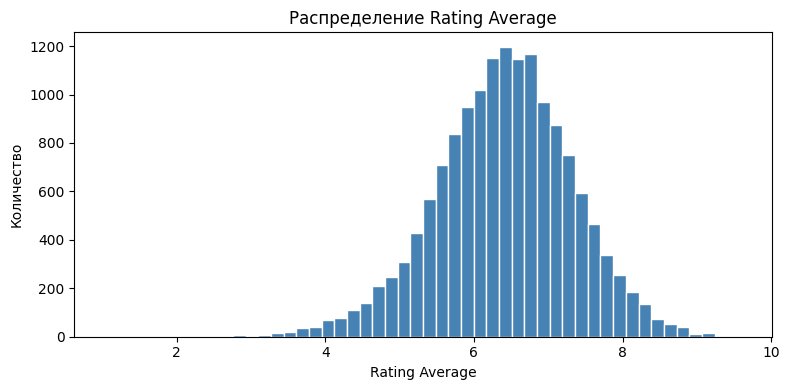

count    15257.000000
mean         6.399775
std          0.936488
min          1.050000
25%          5.820000
50%          6.430000
75%          7.020000
max          9.580000
Name: Rating Average, dtype: float64


In [8]:
plt.figure(figsize=(8, 4))
plt.hist(train['Rating Average'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Распределение Rating Average')
plt.xlabel('Rating Average')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

print(train['Rating Average'].describe())

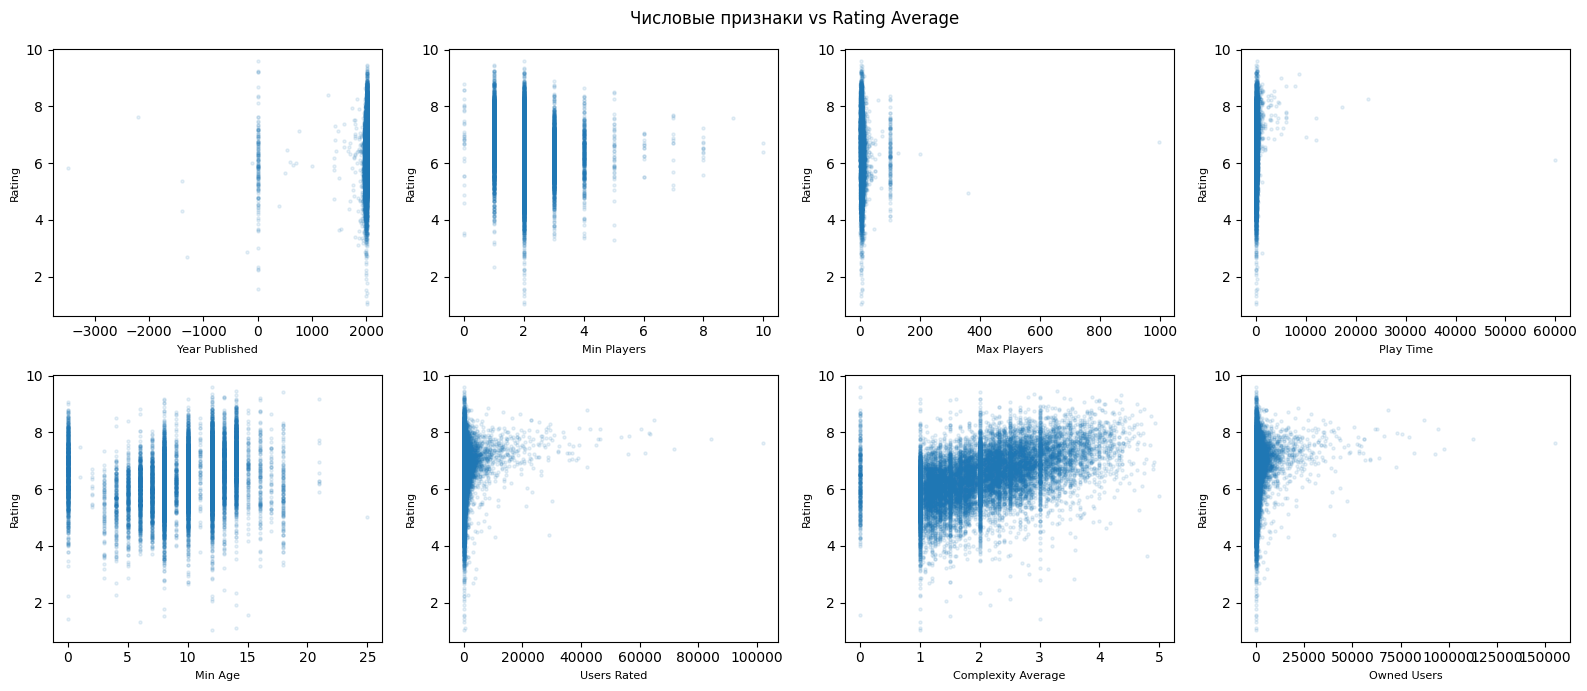

In [9]:
num_cols = ['Year Published', 'Min Players', 'Max Players', 'Play Time',
            'Min Age', 'Users Rated', 'Complexity Average', 'Owned Users']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(train[col], train['Rating Average'], alpha=0.1, s=5)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Rating', fontsize=8)

plt.suptitle('Числовые признаки vs Rating Average')
plt.tight_layout()
plt.show()

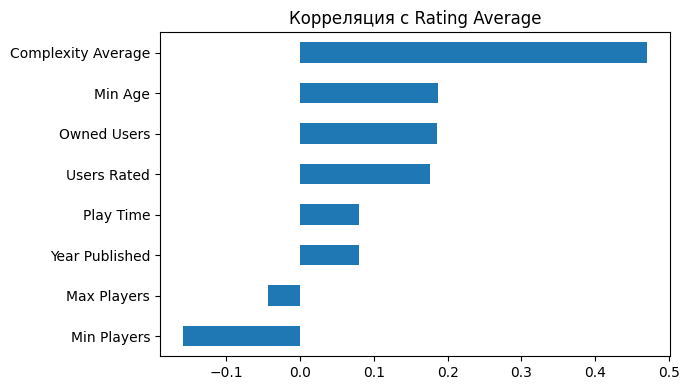

Complexity Average    0.470200
Min Age               0.187403
Owned Users           0.184917
Users Rated           0.175867
Play Time             0.080006
Year Published        0.079546
Max Players          -0.043786
Min Players          -0.158291
Name: Rating Average, dtype: float64


In [10]:
corr = train[num_cols + ['Rating Average']].corr()['Rating Average'].drop('Rating Average').sort_values()
corr.plot(kind='barh', figsize=(7, 4), title='Корреляция с Rating Average')
plt.tight_layout()
plt.show()
print(corr.sort_values(ascending=False))

**Вывод:** Таргет распределён примерно нормально, большинство игр в диапазоне 5.5-8. Сильнее всего с рейтингом коррелирует Complexity Average: более сложные игры оцениваются выше. Users Rated и Owned Users тоже связаны с рейтингом: популярные игры чаще имеют высокие оценки. BGG Rank удалим, это производная от таргета и утечка данных.

## Предобработка

In [11]:
TARGET = 'Rating Average'

DROP_COLS = ['BGG Rank', 'Name', 'ID']

X = train.drop(columns=[TARGET] + DROP_COLS)
y = train[TARGET]

X_test_raw = test.drop(columns=[c for c in DROP_COLS if c in test.columns], errors='ignore')

print('X shape:', X.shape)
print('y:', y.describe())

X shape: (15257, 10)
y: count    15257.000000
mean         6.399775
std          0.936488
min          1.050000
25%          5.820000
50%          6.430000
75%          7.020000
max          9.580000
Name: Rating Average, dtype: float64


In [12]:
def count_tags(series):
    return series.fillna('').apply(lambda x: len(x.split(',')) if x != '' else 0)

for df in [X, X_test_raw]:
    df['mechanics_count'] = count_tags(df['Mechanics'])
    df['domains_count']   = count_tags(df['Domains'])

X = X.drop(columns=['Mechanics', 'Domains'])
X_test_raw = X_test_raw.drop(columns=['Mechanics', 'Domains'])

print('Признаки:', X.columns.tolist())

Признаки: ['Year Published', 'Min Players', 'Max Players', 'Play Time', 'Min Age', 'Users Rated', 'Complexity Average', 'Owned Users', 'mechanics_count', 'domains_count']


In [13]:
for col in X.columns:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    X_test_raw[col] = X_test_raw[col].fillna(median_val)

print('Пропуски в X:', X.isnull().sum().sum())
print('Пропуски в test:', X_test_raw.isnull().sum().sum())

Пропуски в X: 0
Пропуски в test: 0


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print('Train:', X_train.shape, '| Val:', X_val.shape)

Train: (12205, 10) | Val: (3052, 10)


**Вывод:** Удалил BGG Rank как утечку, Name и ID как идентификаторы. Mechanics и Domains преобразовал в числовые признаки, посчитав количество механик и доменов у каждой игры. Пропуски заполнил медианой по трейну.

## Feature Engineering

In [15]:
def add_features(df):
    df = df.copy()

    df['players_range'] = df['Max Players'] - df['Min Players']

    df['log_users_rated'] = np.log1p(df['Users Rated'].clip(lower=0))

    df['log_owned'] = np.log1p(df['Owned Users'].clip(lower=0))

    df['log_playtime'] = np.log1p(df['Play Time'].clip(lower=0))

    return df

X_train_fe = add_features(X_train)
X_val_fe = add_features(X_val)
X_test_fe = add_features(X_test_raw)

print('Признаков после FE:', X_train_fe.shape[1])

Признаков после FE: 14


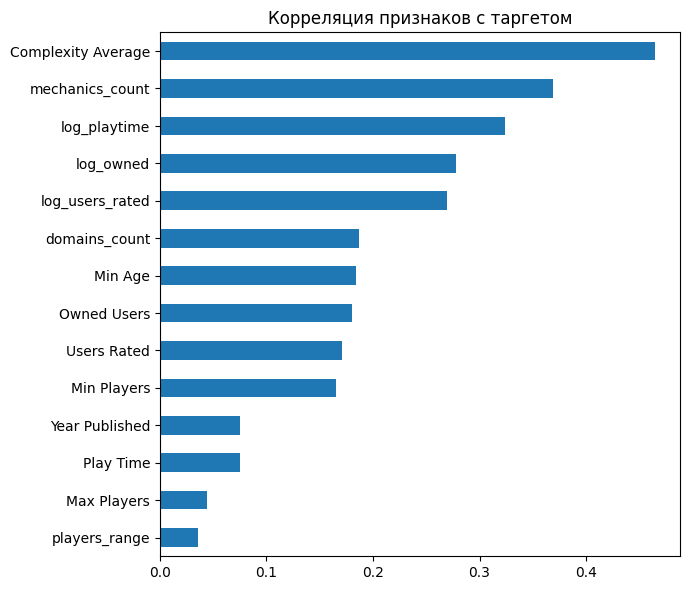

Complexity Average    0.464939
mechanics_count       0.369252
log_playtime          0.324130
log_owned             0.277542
log_users_rated       0.269493
domains_count         0.187191
Min Age               0.184423
Owned Users           0.180070
Users Rated           0.170881
Min Players           0.164926
Year Published        0.074784
Play Time             0.074757
Max Players           0.044387
players_range         0.035978
Name: target, dtype: float64


In [16]:
X_train_fe_tmp = X_train_fe.copy()
X_train_fe_tmp['target'] = y_train.values

corr_all = X_train_fe_tmp.corr()['target'].drop('target').abs().sort_values(ascending=False)

corr_all.plot(kind='barh', figsize=(7, 6), title='Корреляция признаков с таргетом')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(corr_all)

**Вывод:** Добавил 4 новых признака. players_range это диапазон числа игроков, характеризует универсальность игры. Логарифмы Users Rated, Owned Users и Play Time нужны из-за сильно скошенных распределений. По корреляции лидирует Complexity Average, за ним mechanics_count и log_playtime, то есть сложные и механически насыщенные игры имеют более высокие рейтинги.

## Обучение и сравнение моделей

In [17]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_fe)
X_val_sc   = scaler.transform(X_val_fe)

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Ridge':            (Ridge(), True),
    'DecisionTree':     (DecisionTreeRegressor(random_state=SEED), False),
    'KNN':              (KNeighborsRegressor(n_neighbors=5), True),
    'RandomForest':     (RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1), False),
    'GradientBoosting': (GradientBoostingRegressor(n_estimators=200, random_state=SEED), False),
}

results = []
for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train_fe.values
    Xvl = X_val_sc   if use_scaled else X_val_fe.values

    model.fit(Xtr, y_train)
    val_pred  = model.predict(Xvl)
    val_mse   = mean_squared_error(y_val, val_pred)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mse    = -cv_scores.mean()

    results.append({
        'model':   name,
        'cv_mse':  cv_mse,
        'cv_std':  cv_scores.std(),
        'val_mse': val_mse
    })
    print(f'{name:<20} CV MSE: {cv_mse:.4f} ± {cv_scores.std():.4f}  val MSE: {val_mse:.4f}')

res = pd.DataFrame(results).sort_values('val_mse')
res

Ridge                CV MSE: 0.6182 ± 0.0080  val MSE: 0.6372
DecisionTree         CV MSE: 0.8089 ± 0.0210  val MSE: 0.8296
KNN                  CV MSE: 0.6139 ± 0.0127  val MSE: 0.6458
RandomForest         CV MSE: 0.4050 ± 0.0052  val MSE: 0.4393
GradientBoosting     CV MSE: 0.4005 ± 0.0082  val MSE: 0.4249


,model,cv_mse,cv_std,val_mse
4,GradientBoosting,0.400465,0.008167,0.424887
3,RandomForest,0.404962,0.005158,0.439278
0,Ridge,0.618217,0.007958,0.637223
2,KNN,0.613897,0.012734,0.645837
1,DecisionTree,0.808869,0.021026,0.829628


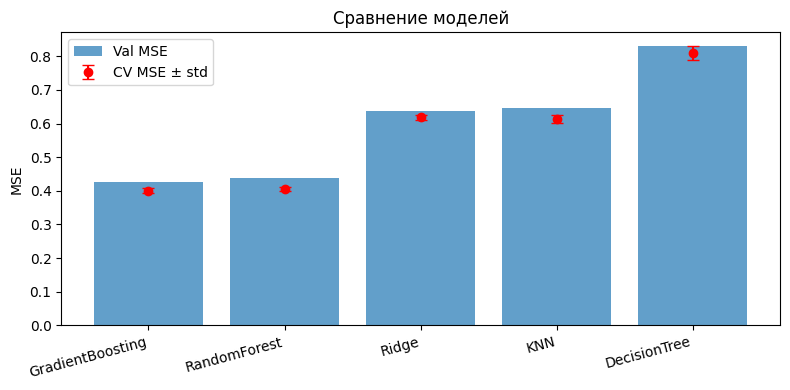

In [18]:
plt.figure(figsize=(8, 4))
x = range(len(res))
plt.bar(x, res['val_mse'], alpha=0.7, label='Val MSE')
plt.errorbar(x, res['cv_mse'], yerr=res['cv_std'], fmt='o', color='red', capsize=4, label='CV MSE ± std')
plt.xticks(x, res['model'], rotation=15, ha='right')
plt.ylabel('MSE')
plt.title('Сравнение моделей')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** Gradient Boosting и Random Forest показывают лучший результат, ансамблевые методы лучше улавливают нелинейные зависимости в данных. Ridge регрессия даёт приемлемый baseline, но существенно уступает. Берём Gradient Boosting для тюнинга, у него стабильнее CV.

## Подбор гиперпараметров (Gradient Boosting)

In [19]:
param_grid = {
    'n_estimators':   [200, 400],
    'max_depth':      [3, 5],
    'learning_rate':  [0.05, 0.1],
    'subsample':      [0.8, 1.0],
}

gs = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train_fe, y_train)

print('Лучшие параметры:', gs.best_params_)
print('CV MSE:          ', round(-gs.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
CV MSE:           0.3947


In [21]:
best = gs.best_estimator_
val_pred_best = best.predict(X_val_fe)
print('Val MSE после тюнинга:', round(mean_squared_error(y_val, val_pred_best), 4))
print('Val RMSE:             ', round(np.sqrt(mean_squared_error(y_val, val_pred_best)), 4))

Val MSE после тюнинга: 0.4204
Val RMSE:              0.6484


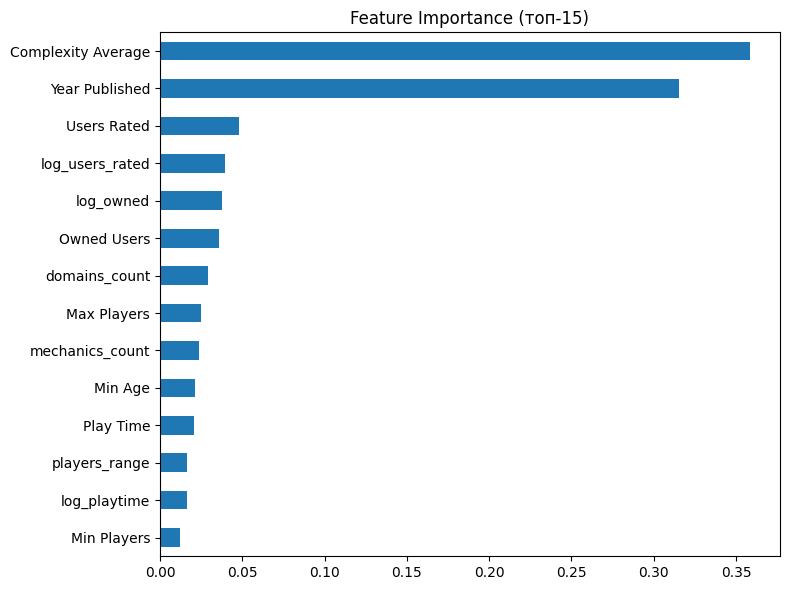

Complexity Average    0.358760
Year Published        0.315607
Users Rated           0.047723
log_users_rated       0.039238
log_owned             0.037562
Owned Users           0.036098
domains_count         0.029330
Max Players           0.024951
mechanics_count       0.023773
Min Age               0.021026
dtype: float64


In [22]:
feat_imp = pd.Series(best.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance (топ-15)')
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

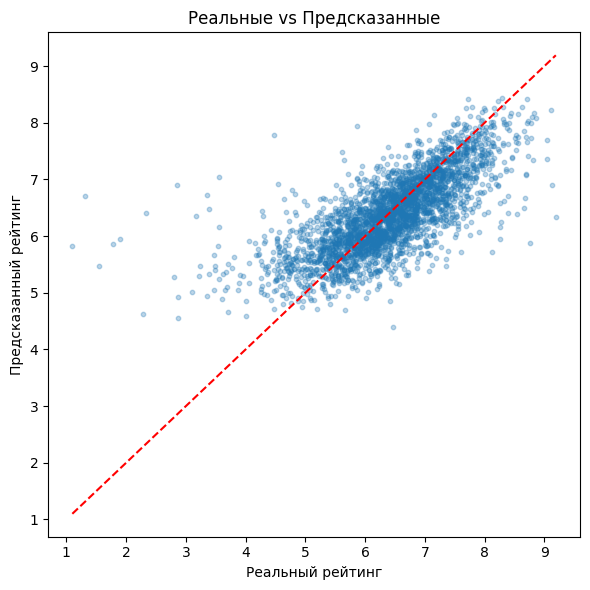

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_pred_best, alpha=0.3, s=10)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Реальный рейтинг')
plt.ylabel('Предсказанный рейтинг')
plt.title('Реальные vs Предсказанные')
plt.tight_layout()
plt.show()

**Вывод:** GridSearchCV подобрал оптимальные параметры, CV MSE снизился до 0.3947. Самые важные признаки — Complexity Average (0.36) и Year Published (0.32). Сложность игры напрямую влияет на оценку, а год выпуска отражает тренд: более современные игры в среднем получают выше рейтинг. Из новых признаков в топ вошли log_owned и log_users_rated, что подтверждает пользу feature engineering.

## Предсказание

In [24]:
X_full_fe = add_features(X)
best.fit(X_full_fe, y)

preds = best.predict(X_test_fe)
print('Предсказания:', preds[:5])
print('Диапазон:', preds.min().round(2), '-', preds.max().round(2))

Предсказания: [7.80901387 7.85293577 7.86073082 8.11675674 7.75290951]
Диапазон: 3.84 - 8.61


**Вывод:** Удалил BGG Rank как утечку, закодировал текстовые признаки Mechanics и Domains через количество тегов, добавил логарифмические преобразования скошенных признаков. Протестировал 5 моделей, лучший результат у Gradient Boosting. После тюнинга гиперпараметров модель переобучена на полном трейне для максимизации качества на тесте.

## Скриншот с лидерборда Kaggle

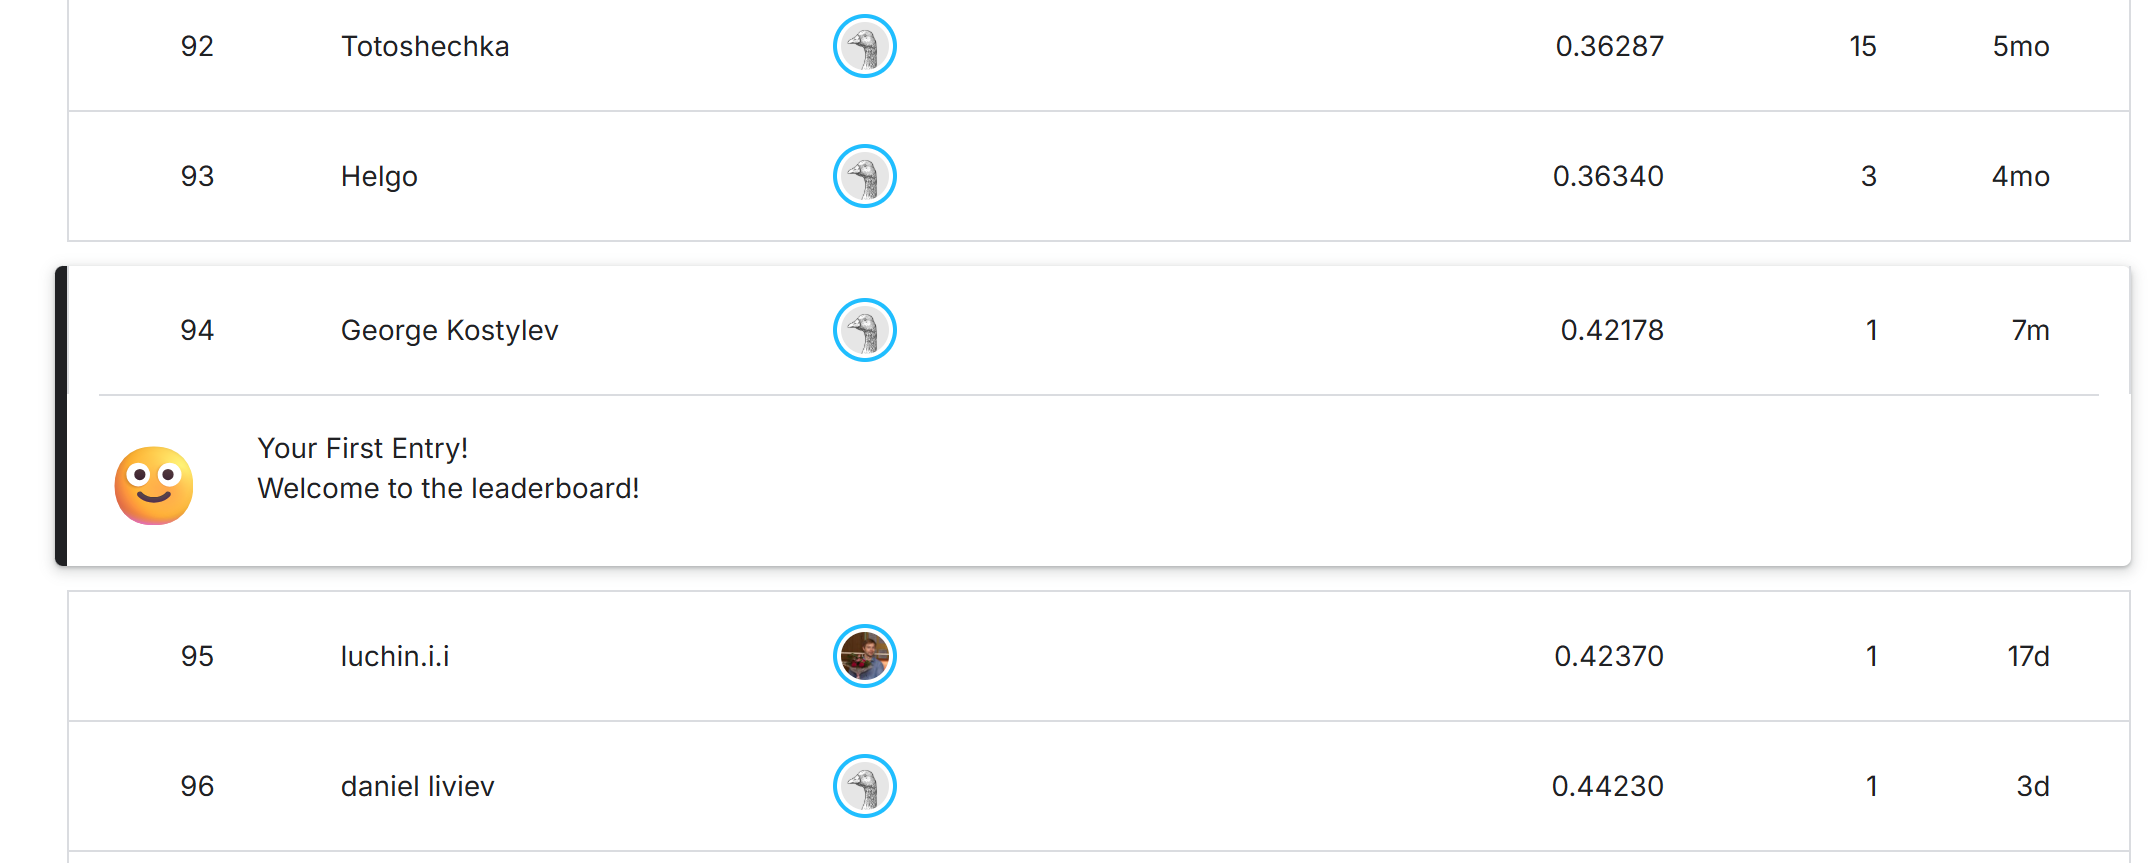